In [20]:
import os
import sys
import re

project_root = "/root/work/tenset"
os.environ["TVM_HOME"] = f"{project_root}"
os.environ["TVM_LIBRARY_PATH"] = f"{project_root}/build"
if f"{project_root}/python" not in sys.path:
    sys.path.insert(0, f"{project_root}/python")

sys.path = [p for p in sys.path if not p.startswith(f"{project_root}/build")]
sys.path.append(f"{project_root}/build")
os.environ["LD_LIBRARY_PATH"] = f"{project_root}/build:" + os.environ.get("LD_LIBRARY_PATH", "")

In [24]:
import sys
sys.path.append("/root/work/tenset/scripts")

from tvm import auto_scheduler
from print_programs import return_program
from tvm.auto_scheduler.feature import get_per_store_features_from_file
from make_dataset import load_and_register_tasks
import numpy as np

json_file = "/root/work/tenset/dataset/measure_records_tenset/k80/([0c9a5ba46ffc5e1a9e5641018527117f,4,7,7,160,1,1,160,960,1,1,1,960,4,7,7,960],cuda).json"

tasks = load_and_register_tasks()
inputs, results = auto_scheduler.RecordReader(json_file).read_lines()
raw_features, raw_normalized_throughputs, task_ids, min_latency = get_per_store_features_from_file(json_file, 10000)

In [25]:
sys.path.insert(0, "/root/work/tenset/scripts/pre_experiments")
from extract_i_vectors import process_only_diff

json_diffs = process_only_diff("/root/work/tenset/dataset/measure_records_tenset/k80/([0c9a5ba46ffc5e1a9e5641018527117f,4,7,7,160,1,1,160,960,1,1,1,960,4,7,7,960],cuda).json", limit=None)
raw_input = json_diffs["diff_values"]
cost = -np.log(json_diffs["cost"])

Bin counts:
  [0.000,0.100): 0
  [0.100,0.200): 0
  [0.200,0.300): 0
  [0.300,0.400): 0
  [0.400,0.500): 0
  [0.500,0.600): 15
  [0.600,0.700): 29
  [0.700,0.800): 294
  [0.800,0.900): 1811
  [0.900,1.000): 20000


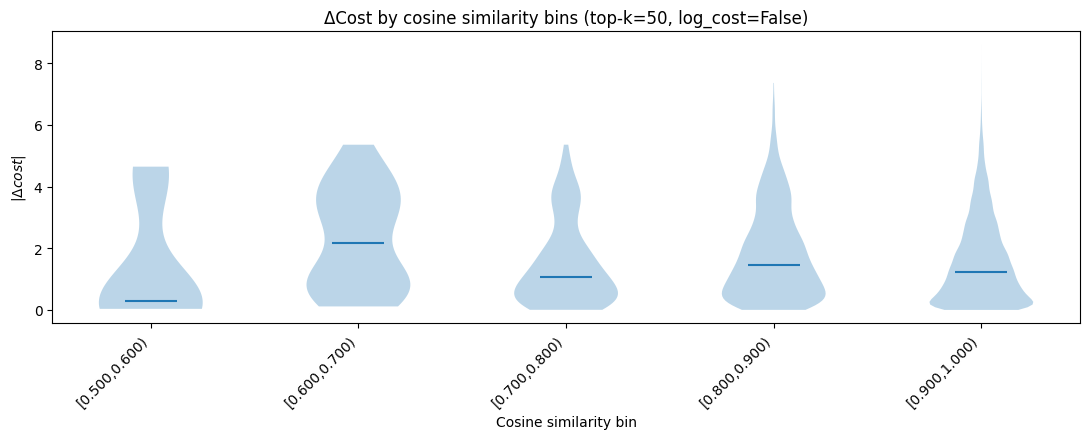

{'bins': array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 'deltas_by_bin': [[],
  [],
  [],
  [],
  [],
  [0.23633060117075289,
   0.034818255604220916,
   0.0778743634261998,
   0.08885958472823052,
   0.08442902383315509,
   3.696982790991232,
   0.2817296516965788,
   4.645564047815624,
   0.07574471051071896,
   0.8749241543238826,
   0.27108118393267944,
   0.2832647773045194,
   0.37610634029158296,
   4.5840680877428515,
   4.566449320866349],
  [0.90881335569643,
   3.641007044343238,
   0.937589022371716,
   0.5297120501314234,
   0.11299856209927484,
   0.6557612941417679,
   0.8904740178062731,
   0.6504926024370636,
   0.8961183567001445,
   0.9565752871957445,
   3.6413190398643787,
   5.356943313372674,
   3.6414513721983237,
   2.810007603905777,
   0.12532368305621322,
   3.6214755277884745,
   0.9620209023108375,
   0.6579239871540015,
   0.6393672584642447,
   4.42366405217577,
   4.6885578201580405,
   3.1974583975965105,
   4.65715484464072,
   2.154

In [26]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def cosine_similarity_matrix(X: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    Xn = X / (norms + eps)
    return Xn @ Xn.T

def plot_cost_delta_by_cosine_bins(
    input_data,
    costs,
    bins=np.linspace(0.0, 1.0, 11),
    k_neighbors=50,
    use_log_cost=True,
    violin=True,
    max_points_per_bin=20000,
    seed=0,
    print_bin_counts=True,
):
    rng = np.random.default_rng(seed)

    # to numpy
    X = input_data.detach().cpu().numpy() if isinstance(input_data, torch.Tensor) else np.asarray(input_data)
    y = costs.detach().cpu().numpy() if isinstance(costs, torch.Tensor) else np.asarray(costs)

    assert X.ndim == 2, f"input_data must be [N,D], got {X.shape}"
    assert y.ndim == 1 and y.shape[0] == X.shape[0], f"costs must be [N], got {y.shape}"

    # cost transform
    if use_log_cost:
        y_safe = np.maximum(y, 1e-12)
        y_t = np.log(y_safe)
        y_label = r"$|\Delta \log(cost)|$"
    else:
        y_t = y
        y_label = r"$|\Delta cost|$"

    N = X.shape[0]
    S = cosine_similarity_matrix(X)

    deltas = [[] for _ in range(len(bins) - 1)]

    for i in range(N):
        sims = S[i].copy()
        sims[i] = -np.inf

        k = min(k_neighbors, N - 1)
        nn_idx = np.argpartition(-sims, kth=k-1)[:k]

        for j in nn_idx:
            if j <= i:
                continue
            cos_ij = S[i, j]
            dcost = abs(y_t[i] - y_t[j])

            b = np.searchsorted(bins, cos_ij, side="right") - 1
            if 0 <= b < len(deltas):
                deltas[b].append(dcost)

    # subsample + build labels
    deltas_sub, labels, counts = [], [], []
    for b in range(len(deltas)):
        arr = np.asarray(deltas[b], dtype=np.float32)
        if arr.size > max_points_per_bin:
            idx = rng.choice(arr.size, size=max_points_per_bin, replace=False)
            arr = arr[idx]
        deltas_sub.append(arr)
        labels.append(f"[{bins[b]:.3f},{bins[b+1]:.3f})")
        counts.append(arr.size)

    if print_bin_counts:
        print("Bin counts:")
        for lab, c in zip(labels, counts):
            print(f"  {lab}: {c}")

    # ---- FIX: drop empty bins for plotting ----
    nonempty_idx = [i for i, a in enumerate(deltas_sub) if a.size > 0]
    if len(nonempty_idx) == 0:
        raise ValueError("All bins are empty. Try increasing k_neighbors or adjusting bins range.")

    plot_data = [deltas_sub[i] for i in nonempty_idx]
    plot_labels = [labels[i] for i in nonempty_idx]

    plt.figure(figsize=(11, 4.5))
    if violin:
        plt.violinplot(
            plot_data,
            showmeans=False,
            showmedians=True,
            showextrema=False,
        )
    else:
        plt.boxplot(plot_data, showfliers=False)

    plt.xticks(np.arange(1, len(plot_labels) + 1), plot_labels, rotation=45, ha="right")
    plt.ylabel(y_label)
    plt.xlabel("Cosine similarity bin")
    plt.title(f"ΔCost by cosine similarity bins (top-k={k_neighbors}, log_cost={use_log_cost})")
    plt.tight_layout()
    plt.show()

    return {"bins": bins, "deltas_by_bin": deltas, "bin_counts": counts}

# 사용:
plot_cost_delta_by_cosine_bins(raw_input, cost, k_neighbors=50, use_log_cost=False, violin=True)


In [5]:
# records = {
#     "schedules": [],
#     "cost_mean": [],
#     "feature" : []
# }

# for i in range(len(inputs)):
#     state, cost = return_program(inputs[i], results[i])
#     # break
#     if state is not None:
#         cost_mean = np.mean([x.value for x in cost])
#         feature = raw_features[i]
#         records["feature"].append(feature)
#         records["schedules"].append(state)
#         records["cost_mean"].append(cost_mean)


# features = np.array(records["feature"], dtype=np.float32)
# costs = np.array(records["cost_mean"], dtype=np.float32) * 1000

# features = features.sum(axis=1)

In [6]:
features = []
costs = []
for feature, throughput in zip(raw_features, raw_normalized_throughputs):
    if throughput > 1.0e-10:
        features.append(feature)
        costs.append(-np.log(throughput))


features = np.array(features, dtype=np.float32)
costs = np.array(costs, dtype=np.float32)

features = features.sum(axis=1)

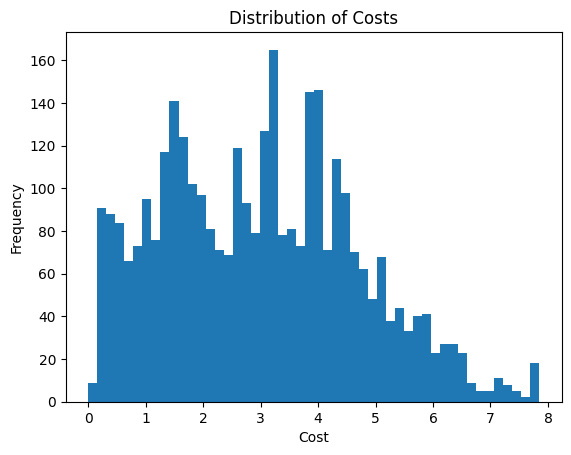

In [18]:
import matplotlib.pyplot as plt
costs = np.array(costs)
# Convert the negative log costs back to positive costs for better interpretability
# costs = np.exp(-costs)
plt.hist(costs, bins=50)
plt.xlabel("Cost")
plt.ylabel("Frequency")
plt.title("Distribution of Costs")
plt.show()

Bin counts:
  [0.900,0.902): 0
  [0.902,0.904): 0
  [0.904,0.906): 0
  [0.906,0.908): 0
  [0.908,0.910): 0
  [0.910,0.912): 0
  [0.912,0.914): 0
  [0.914,0.916): 0
  [0.916,0.918): 0
  [0.918,0.920): 0
  [0.920,0.922): 0
  [0.922,0.924): 0
  [0.924,0.926): 0
  [0.926,0.928): 0
  [0.928,0.930): 0
  [0.930,0.932): 0
  [0.932,0.934): 0
  [0.934,0.936): 0
  [0.936,0.938): 0
  [0.938,0.940): 0
  [0.940,0.942): 0
  [0.942,0.944): 0
  [0.944,0.946): 0
  [0.946,0.948): 0
  [0.948,0.950): 0
  [0.950,0.952): 0
  [0.952,0.954): 0
  [0.954,0.956): 0
  [0.956,0.958): 0
  [0.958,0.960): 0
  [0.960,0.962): 0
  [0.962,0.964): 0
  [0.964,0.966): 0
  [0.966,0.968): 0
  [0.968,0.970): 0
  [0.970,0.972): 0
  [0.972,0.974): 0
  [0.974,0.976): 29
  [0.976,0.978): 2
  [0.978,0.980): 5
  [0.980,0.982): 7
  [0.982,0.984): 16
  [0.984,0.986): 59
  [0.986,0.988): 129
  [0.988,0.990): 291
  [0.990,0.992): 464
  [0.992,0.994): 1039
  [0.994,0.996): 3406
  [0.996,0.998): 8680
  [0.998,1.000): 20000


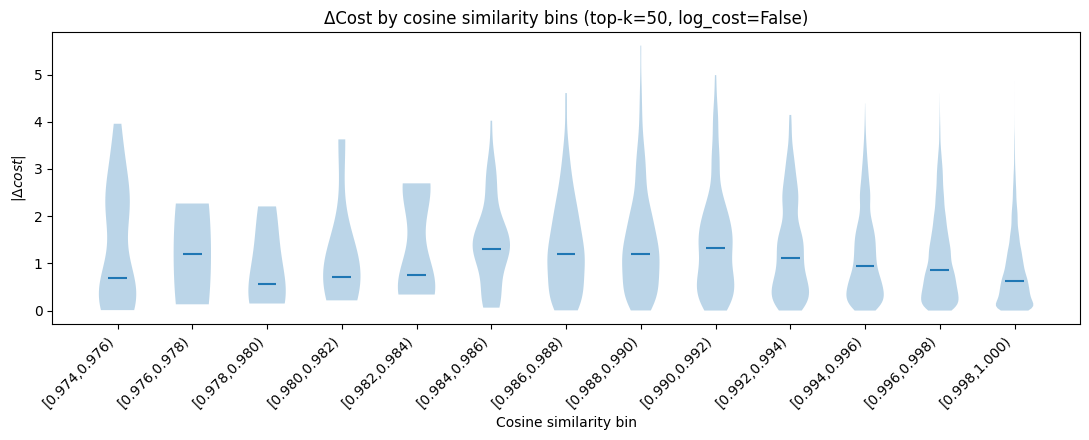

{'bins': array([0.9  , 0.902, 0.904, 0.906, 0.908, 0.91 , 0.912, 0.914, 0.916,
        0.918, 0.92 , 0.922, 0.924, 0.926, 0.928, 0.93 , 0.932, 0.934,
        0.936, 0.938, 0.94 , 0.942, 0.944, 0.946, 0.948, 0.95 , 0.952,
        0.954, 0.956, 0.958, 0.96 , 0.962, 0.964, 0.966, 0.968, 0.97 ,
        0.972, 0.974, 0.976, 0.978, 0.98 , 0.982, 0.984, 0.986, 0.988,
        0.99 , 0.992, 0.994, 0.996, 0.998, 1.   ]),
 'deltas_by_bin': [[],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [0.67677635,
   0.16501546,
   0.009781241,
   2.0191002,
   0.18292451,
   3.95722,
   0.4026252,
   0.121471286,
   2.4431372,
   0.845046,
   3.4958267,
   2.8757834,
   0.651116,
   2.8443732,
   0.15417457,
   0.18745351,
   2.1668625,
   0.42788947,
   0.67398095,
   1.9132267,
   0.06574714,
   0.124231815,
   2.1403952,
   2.204082,
 

In [27]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def cosine_similarity_matrix(X: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    Xn = X / (norms + eps)
    return Xn @ Xn.T

def plot_cost_delta_by_cosine_bins(
    input_data,
    costs,
    bins=np.linspace(0.9, 1.0, 51),
    k_neighbors=50,
    use_log_cost=True,
    violin=True,
    max_points_per_bin=20000,
    seed=0,
    print_bin_counts=True,
):
    rng = np.random.default_rng(seed)

    # to numpy
    X = input_data.detach().cpu().numpy() if isinstance(input_data, torch.Tensor) else np.asarray(input_data)
    y = costs.detach().cpu().numpy() if isinstance(costs, torch.Tensor) else np.asarray(costs)

    assert X.ndim == 2, f"input_data must be [N,D], got {X.shape}"
    assert y.ndim == 1 and y.shape[0] == X.shape[0], f"costs must be [N], got {y.shape}"

    # cost transform
    if use_log_cost:
        y_safe = np.maximum(y, 1e-12)
        y_t = np.log(y_safe)
        y_label = r"$|\Delta \log(cost)|$"
    else:
        y_t = y
        y_label = r"$|\Delta cost|$"

    N = X.shape[0]
    S = cosine_similarity_matrix(X)

    deltas = [[] for _ in range(len(bins) - 1)]

    for i in range(N):
        sims = S[i].copy()
        sims[i] = -np.inf

        k = min(k_neighbors, N - 1)
        nn_idx = np.argpartition(-sims, kth=k-1)[:k]

        for j in nn_idx:
            if j <= i:
                continue
            cos_ij = S[i, j]
            dcost = abs(y_t[i] - y_t[j])

            b = np.searchsorted(bins, cos_ij, side="right") - 1
            if 0 <= b < len(deltas):
                deltas[b].append(dcost)

    # subsample + build labels
    deltas_sub, labels, counts = [], [], []
    for b in range(len(deltas)):
        arr = np.asarray(deltas[b], dtype=np.float32)
        if arr.size > max_points_per_bin:
            idx = rng.choice(arr.size, size=max_points_per_bin, replace=False)
            arr = arr[idx]
        deltas_sub.append(arr)
        labels.append(f"[{bins[b]:.3f},{bins[b+1]:.3f})")
        counts.append(arr.size)

    if print_bin_counts:
        print("Bin counts:")
        for lab, c in zip(labels, counts):
            print(f"  {lab}: {c}")

    # ---- FIX: drop empty bins for plotting ----
    nonempty_idx = [i for i, a in enumerate(deltas_sub) if a.size > 0]
    if len(nonempty_idx) == 0:
        raise ValueError("All bins are empty. Try increasing k_neighbors or adjusting bins range.")

    plot_data = [deltas_sub[i] for i in nonempty_idx]
    plot_labels = [labels[i] for i in nonempty_idx]

    plt.figure(figsize=(11, 4.5))
    if violin:
        plt.violinplot(
            plot_data,
            showmeans=False,
            showmedians=True,
            showextrema=False,
        )
    else:
        plt.boxplot(plot_data, showfliers=False)

    plt.xticks(np.arange(1, len(plot_labels) + 1), plot_labels, rotation=45, ha="right")
    plt.ylabel(y_label)
    plt.xlabel("Cosine similarity bin")
    plt.title(f"ΔCost by cosine similarity bins (top-k={k_neighbors}, log_cost={use_log_cost})")
    plt.tight_layout()
    plt.show()

    return {"bins": bins, "deltas_by_bin": deltas, "bin_counts": counts}

# 사용:
plot_cost_delta_by_cosine_bins(features, costs, k_neighbors=50, use_log_cost=False, violin=True)


In [4]:
import torch
import torch.nn as nn

class MLPRegressor(nn.Module):
    def __init__(self, in_dim, hidden_dim=256):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )

        self.net = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        
        
        h = self.encoder(x)
        # torch N*4,D -> N,4,D
        h = h.view(-1, 4, h.size(-1))
        # 평균값 계산 N,4,D -> N,D
        h_mean = torch.mean(h, dim=1)
        return self.net(h_mean)



In [5]:
from torch.nn import functional as F
def pairwise_ranking_loss(cost_pred, cost_true, margin=0.1):
    """
    Pairwise ranking loss: 실제 cost 순서를 예측이 유지하도록.
    cost_true[i] < cost_true[j] 이면 cost_pred[i] < cost_pred[j] + margin
    """
    batch_size = cost_pred.size(0)
    if batch_size < 2:
        return torch.tensor(0.0, device=cost_pred.device)
    
    # 모든 쌍에 대해 ranking loss 계산
    idx = torch.arange(batch_size, device=cost_pred.device)
    i_idx, j_idx = torch.meshgrid(idx, idx, indexing='ij')
    mask = i_idx < j_idx  # upper triangular only
    
    pred_i = cost_pred[i_idx[mask]]
    pred_j = cost_pred[j_idx[mask]]
    true_i = cost_true[i_idx[mask]]
    true_j = cost_true[j_idx[mask]]
    
    # label: 1 if true_i < true_j, -1 otherwise
    labels = torch.sign(true_j - true_i).float()
    
    # Margin ranking loss
    loss = F.margin_ranking_loss(pred_j.view(-1), pred_i.view(-1), labels.view(-1), margin=margin)
    return loss

def reg_loss_fn(cost_pred, cost_true, loss_type='mse'):
    """
    기본 회귀 손실 (MSE 또는 MAE)
    """
    if loss_type == 'mse':
        return F.mse_loss(cost_pred, cost_true)
    else:  # mae
        return F.l1_loss(cost_pred, cost_true)
    
def total_loss_fn(cost_pred, cost_true, alpha=0.5, margin=0.1):
    """
    회귀 손실과 쌍별 순위 손실의 가중 합
    """
    reg_loss = reg_loss_fn(cost_pred, cost_true, loss_type='mse')
    rank_loss = pairwise_ranking_loss(cost_pred, cost_true, margin=margin)
    return alpha * reg_loss + rank_loss

In [6]:
def pair_accuracy(cost_pred, labels):
    """
    cost_pred, labels: (B,) 텐서
    """
    n_samples = min(1000, len(cost_pred))
    sample_indices = np.random.choice(len(cost_pred), n_samples, replace=False)

    with torch.no_grad():
        correct = 0
        total = 0
        for i in range(n_samples):
            for j in range(i + 1, n_samples):
                idx_i = sample_indices[i]
                idx_j = sample_indices[j]
                pred_diff = cost_pred[idx_i] - cost_pred[idx_j]
                true_diff = labels[idx_i] - labels[idx_j]
                if (pred_diff * true_diff) > 0:
                    correct += 1
                total += 1
        accuracy = correct / total if total > 0 else 0.0
    return accuracy

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import DataLoader, Dataset

class NpzRegressionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float()
        # y shape이 (N,)이면 (N,1)로 바꿔주는 게 편할 때가 많음
        if self.y.ndim == 1:
            self.y = self.y.unsqueeze(1)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_size = 64
random_indices = np.random.permutation(len(features))[:train_size]
features_64 = features[random_indices]
costs_64 = costs[random_indices]
X_train = features_64
y_train = costs_64
X_val = features[~np.isin(np.arange(len(features)), random_indices)]
y_val = costs[~np.isin(np.arange(len(costs)), random_indices)]

# X_train, X_val, y_train, y_val = train_test_split(
#     features, costs, test_size=0.2, random_state=42
# )

X_train_flat = X_train.reshape(X_train.shape[0] * X_train.shape[1], X_train.shape[2])
X_val_flat = X_val.reshape(X_val.shape[0] * X_val.shape[1], X_val.shape[2])

scaler = StandardScaler()
X_train_flat_scaled = scaler.fit_transform(X_train_flat)
X_val_flat_scaled = scaler.transform(X_val_flat)
X_train_scaled = X_train_flat_scaled.reshape(X_train.shape[0], X_train.shape[1], X_train.shape[2])
X_val_scaled = X_val_flat_scaled.reshape(X_val.shape[0], X_val.shape[1], X_val.shape[2])

train_dataset = NpzRegressionDataset(X_train_scaled, y_train)
val_dataset   = NpzRegressionDataset(X_val_scaled,   y_val)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=128, shuffle=False)

In [11]:
num_epochs = 200
input_dim = X_train.shape[-1]
model = MLPRegressor(input_dim, hidden_dim=256)


# criterion = nn.MarginRankingLoss(margin=0.01)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

for epoch in range(1, num_epochs+1):
    # --- train ---
    model.train()
    train_loss = 0.0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        yb = yb.squeeze()
        # flatten input N,4,D -> N*4,D
        xb = xb.view(xb.size(0) * xb.size(1), xb.size(2))

        pred = model(xb)
        loss = total_loss_fn(pred, yb, alpha=0.01, margin=0.01)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)

    train_loss /= len(train_dataset)

    # --- validation ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            yb = yb.squeeze()
            xb = xb.view(xb.size(0) * xb.size(1), xb.size(2))

            pred = model(xb)
            loss = total_loss_fn(pred, yb, alpha=0.01, margin=0.01)
            val_loss += loss.item() * xb.size(0)

    val_loss /= len(val_dataset)

    if (epoch) % 50 == 0:
        print(f"Epoch [{epoch}/{num_epochs}] "
              f"train_loss={train_loss:.4f} val_loss={val_loss:.4f}")



/tmp/ipykernel_629101/247624797.py:33: UserWarning: Using a target size (torch.Size([64])) that is different to the input size (torch.Size([64, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(cost_pred, cost_true)
/tmp/ipykernel_629101/247624797.py:33: UserWarning: Using a target size (torch.Size([128])) that is different to the input size (torch.Size([128, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(cost_pred, cost_true)
/tmp/ipykernel_629101/247624797.py:33: UserWarning: Using a target size (torch.Size([116])) that is different to the input size (torch.Size([116, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(cost_pred, cost_true)


Epoch [50/200] train_loss=0.1069 val_loss=0.1823
Epoch [100/200] train_loss=0.0962 val_loss=0.1771
Epoch [150/200] train_loss=0.0959 val_loss=0.1759
Epoch [200/200] train_loss=0.0959 val_loss=0.1758


In [12]:
rank_inputs = torch.from_numpy(features).float().to(device)
rank_inputs = rank_inputs.view(rank_inputs.size(0) * rank_inputs.size(1), rank_inputs.size(2))
rank_labels = torch.from_numpy(costs).float().to(device)
pred = model(rank_inputs)
rank_r2 = pair_accuracy(pred, rank_labels)
print(f"Final Pairwise Ranking Accuracy: {rank_r2:.4f}")

Final Pairwise Ranking Accuracy: 0.4006
